In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import string
import re

from metpy.calc import wind_direction, wind_speed
from metpy.units import units

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import BoundaryNorm
from datetime import datetime, timedelta
from suntimes import SunTimes

from cmcrameri import cm

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Helvetica',
    'Nimbus Sans',
    'Arial',
    'Liberation Sans'
]

data_dir = '../data_out/'
fig_png_dir = '../figures/png/'
fig_pdf_dir = '../figures/pdf/'

In [2]:
def get_df_from_nc(ds, var):
    time_dim = ds[var].dims[0]
    height_dim = ds[var].dims[1]
    df = pd.DataFrame(ds[var].values, columns=ds[height_dim], index=pd.to_datetime(ds[time_dim],utc=True))
    return df.loc[dt_from:dt_to,:]

## Script settings

In [3]:
date = '2025-08-10'
days = 1

# resample WindRanger from 10min to 30min
res_wr = False

## Get data and resample

The data used for this figure is available at Zenodo:

[![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.19596272.svg)](https://doi.org/10.5281/zenodo.19596272)

In [4]:
# prepare dates
dt_from = pd.to_datetime(date,utc=True)
dt_to = dt_from + timedelta(days=days)

# load data
ds_icon = xr.open_dataset(data_dir + 'icon/HEFEX3__ICON_v370_2030_cid35704_75ml__avg30min_20250805-20250905.nc')
ds_wr   = xr.open_dataset(data_dir + 'obs/HEFEX3__Obs_WindRanger_L1__avg30min_20250807-20250831.nc')

df_i_wspd = get_df_from_nc(ds_icon, 'wspd')
df_i_wdir = get_df_from_nc(ds_icon, 'wdir')

if res_wr:
    df_wr_u = get_df_from_nc(ds_wr, 'u').resample('30min', origin='end_day').mean()
    df_wr_v = get_df_from_nc(ds_wr, 'v').resample('30min', origin='end_day').mean()

    # calc wind direction and speed
    df_wr_wspd = pd.DataFrame(wind_speed(df_wr_u.values * units('m/s'), df_wr_v.values * units('m/s')), index=df_wr_u.index, columns=df_wr_u.columns)
    df_wr_wdir = pd.DataFrame(wind_direction(df_wr_u.values * units('m/s'), df_wr_v.values * units('m/s')), index=df_wr_u.index, columns=df_wr_u.columns)
else:
    df_wr_wspd = get_df_from_nc(ds_wr, 'wspd')
    df_wr_wdir = get_df_from_nc(ds_wr, 'wdir')

# get coords from metadata
coords = ds_wr.attrs['location'].split(':')[1].split(',')
lon,lat,alt = [float(re.search(r'[-+]?\d*\.?\d+', s).group()) for s in coords]
suntimes = SunTimes(longitude=lon, latitude=lat, altitude=alt)

## Create plot

In [5]:
from matplotlib.colors import ListedColormap, BoundaryNorm
base = plt.get_cmap(cm.romaO)

# 8 directions
colors8 = base(np.linspace(0, 1, 8, endpoint=False))
# colors8 = base(np.linspace(0, 1, 4, endpoint=False))

# duplicate North color at the end
colors9 = np.vstack([colors8, colors8[0]])

cmap = ListedColormap(colors9)

bounds = [
    0,
    22.5,
    67.5,
    112.5,
    157.5,
    202.5,
    247.5,
    292.5,
    337.5,
    360,
]

# bounds = [
#     0,
#     45,
#     135,
#     225,
#     315,
#     360,
# ]
norm = BoundaryNorm(bounds, cmap.N)


2025-08-10 05:29:00+00:00
2025-08-10 16:39:00+00:00


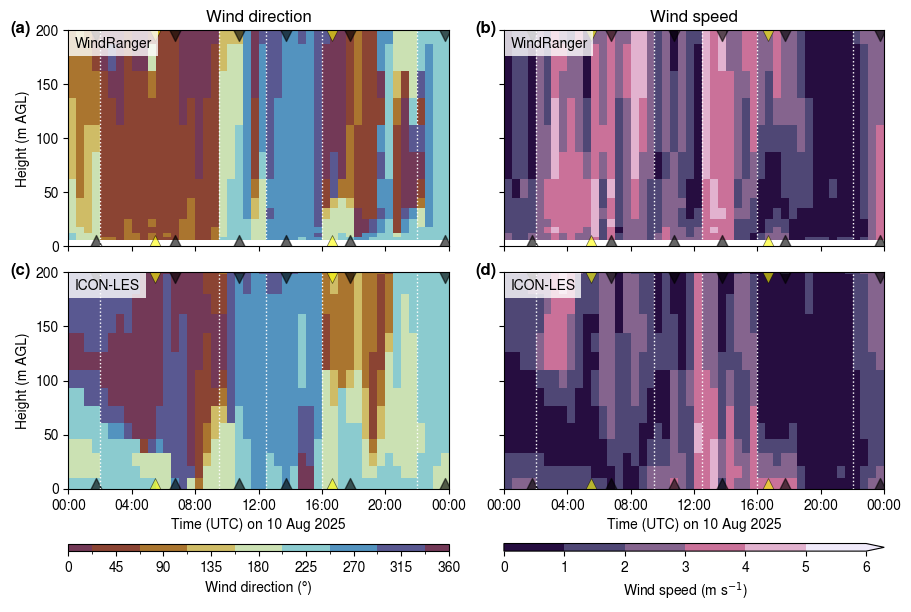

In [15]:
fig, axs = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(9, 6), constrained_layout=True)

# Wind Direction
cmap_wdir = cmap #cm.romaO
norm_wdir = norm #BoundaryNorm(np.arange(0, 361, 45), cmap_wdir.N)

ax = axs[0][0]
pc = ax.pcolormesh(df_wr_wdir.index-pd.Timedelta(minutes=15), df_wr_wdir.columns, df_wr_wdir.T, shading='auto', cmap=cmap_wdir, norm=norm_wdir)
ax.set_ylabel('Height (m AGL)')
ax.set_title('Wind direction')

ax = axs[1][0]
pc = ax.pcolormesh(df_i_wdir.index-pd.Timedelta(minutes=15), df_i_wdir.columns, df_i_wdir.T, shading='auto', cmap=cmap_wdir, norm=norm_wdir)
# cbar = fig.colorbar(pc, ax=ax, orientation='horizontal', aspect=50)
cbar = fig.colorbar(
    pc,
    ax=ax,
    orientation='horizontal', aspect=50,
    boundaries=bounds,
    spacing="proportional",
    #pad=0.02
)


cbar.set_label('Wind direction (°)')
cbar.set_ticks(np.arange(0, 361, 45))
ax.set_ylabel('Height (m AGL)')

# Wind Speed
cmap_wspd = cm.acton
norm_wspd = BoundaryNorm(np.arange(0, 7, 1), cmap_wspd.N)

ax = axs[0][1]
pc = ax.pcolormesh(df_wr_wspd.index-pd.Timedelta(minutes=15), df_wr_wspd.columns, df_wr_wspd.T, shading='auto', cmap=cmap_wspd, norm=norm_wspd)
ax.set_title('Wind speed')

ax = axs[1][1]
pc = ax.pcolormesh(df_i_wspd.index-pd.Timedelta(minutes=15), df_i_wspd.columns, df_i_wspd.T, shading='auto', cmap=cmap_wspd, norm=norm_wspd)
cbar = fig.colorbar(pc, ax=ax, orientation='horizontal', aspect=50, extend='max')
cbar.set_label('Wind speed (m s$^{-1}$)')

# Formatting
for i,ax in enumerate(axs.flat):
    ax.set_xlim(dt_from, dt_to)
    ax.set_ylim(0,200)

    if i // 2 == 0:
        l='WindRanger'
    else:
        l='ICON-LES'
        # ax.set_xlabel(f"Time (UTC) on {dt_from.strftime('%Y-%m-%d')}")
        ax.set_xlabel(f"Time (UTC) on {dt_from.strftime('%d %b %Y')}")
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))

    # box in upper left corner
    ax.text(
        0.017, 0.97, l, ha="left", va="top", fontsize=10,
        transform=ax.transAxes,  # axis coordinates
        bbox=dict(
            facecolor="white", edgecolor="none",
            alpha=0.8, boxstyle="square,pad=0.4"
        )
    )

# panel letters
for ax, letter in zip(axs.flat, string.ascii_lowercase):
    if letter in ['a','c']: x=-0.1
    else: x=-0.02
    ax.text(
        x, .97, f'({letter})',
        transform=ax.transAxes,
        fontsize=12, fontweight='bold',
        va='bottom', ha='right'
    )

for h in [#suntimes.risewhere(dt_from, 'UTC'), suntimes.setwhere(dt_from, 'UTC'),
          pd.to_datetime('2025-08-10 05:29', utc=True), pd.to_datetime('2025-08-10 16:39', utc=True)]:
    print(h)
    for ax in axs.flat:
        ax.scatter(h,200, color='yellow', s=250, marker='v', edgecolor='k', lw=.5, alpha=.6)
        ax.scatter(h,0, color='yellow', s=250, marker='^', edgecolor='k', lw=.5, alpha=.6)

for h in [2,7,11,14,18,24]:
    for ax in axs.flat:
        dt = dt_from + timedelta(hours=h) - pd.Timedelta(minutes=15)
        ax.scatter(dt,200, color='black', s=250, marker='v', alpha=.6)
        ax.scatter(dt,0, color='black', s=250, marker='^', alpha=.6)

for h in ['02:00','09:30','12:30','16:00','22:00']:
    for ax in axs.flat:
        ax.axvline(pd.to_datetime(f"{dt_from.strftime('%Y-%m-%d')} {h}", utc=True), color='white', linestyle=':', lw=1)

plt.savefig(fig_png_dir + f'HEF_WindRanger_ICON_profile_{dt_from.strftime("%Y%m%d")}_new.png', dpi=150, bbox_inches = 'tight', pad_inches = 0)
plt.savefig(fig_pdf_dir + f'HEF_WindRanger_ICON_profile_{dt_from.strftime("%Y%m%d")}_new.pdf', dpi=300, bbox_inches = 'tight', pad_inches = 0)
plt.show()

---

In [ ]:
from ICONProcessor import ICONDataGrid

file = '/Users/geoalxx/Python/glacier_space/data_icon_h3/levante_v370_2030/v370_2030_LES_30min_51m_ml_35704.nc'
ds = xr.open_dataset(file)

df_icon = pd.DataFrame()
df_icon['dt'] = [ICONDataGrid.convert_float_dt(f) for f in ds.time.values]
df_icon.set_index('dt', inplace=True)
df_icon['u'] = ds.u_10m.values[:,0,0]
df_icon['v'] = ds.v_10m.values[:,0,0]
df_icon['wdir'] = wind_direction(ds.u_10m.values[:,0,0] * units('m/s'), ds.v_10m.values[:,0,0] * units('m/s'))
df_icon = df_icon.loc[dt_from:dt_to]


file = '/Users/geoalxx/Python/glacier_space/data_icon_h3/levante_v370_2030/v370_2030_LES_51m_pl_35704.nc'
ds = xr.open_dataset(file)
df_tmp = pd.DataFrame()
df_tmp['dt'] = [ICONDataGrid.convert_float_dt(f) for f in ds.time.values]
df_tmp.set_index('dt', inplace=True)
df_tmp['u'] = ds.u.values[:,0,0]
df_tmp['v'] = ds.v.values[:,0,0]
df_tmp['wdir_500'] = wind_direction(df_tmp['u'].values * units('m/s'), df_tmp['v'].values * units('m/s'))
df_tmp['wspd_500'] = wind_speed(df_tmp['u'].values * units('m/s'), df_tmp['v'].values * units('m/s'))
df_tmp = df_tmp.loc[dt_from:dt_to][['wdir_500','wspd_500']]

df_icon = df_icon.merge(df_tmp, how='outer', left_index=True, right_index=True)

df_icon.index = df_icon.index.tz_localize(None)

In [ ]:
file1 = '/Users/geoalxx/HEFEX III/_processed/L2/gill_L2_1s_10min_res.nc'
file2 = '/Users/geoalxx/HEFEX III/_processed/L2/metek_L2_20Hz_10min_res.nc'

df = pd.DataFrame()

ds = xr.open_dataset(file1)
for h in ds.heights.values:
    df_tmp = ds.Wdir.sel(time=slice(dt_from.tz_localize(None), dt_to.tz_localize(None))).sel(heights=h).to_dataframe()
    df_tmp.rename(columns={'Wdir': f'Wdir_{h}m'}, inplace=True)
    df = df.merge(df_tmp[f'Wdir_{h}m'], how='outer', left_index=True, right_index=True)

ds = xr.open_dataset(file2)
for h in ds.heights.values:
    df_tmp = ds.Wdir.sel(time=slice(dt_from.tz_localize(None), dt_to.tz_localize(None))).sel(heights=h).to_dataframe()
    df_tmp.rename(columns={'Wdir': f'Wdir_{h}m'}, inplace=True)
    df = df.merge(df_tmp[f'Wdir_{h}m'], how='outer', left_index=True, right_index=True)

df

In [ ]:
import matplotlib.dates as mdates

fig,ax=plt.subplots(1,1,figsize=(12,5))

ax.scatter(df.index, df['Wdir_9.0m'], label='9m',s=5)
#ax.scatter(df.index, df['Wdir_7m'], label='7m',s=5)
ax.scatter(df.index, df['Wdir_5.0m'], label='5m',s=5)
#ax.scatter(df.index, df['Wdir_4m'], label='4m',s=5)
#ax.scatter(df.index, df['Wdir_3.0m'], label='3m',s=5)
ax.scatter(df.index, df['Wdir_2m'], label='2m',s=5)
ax.scatter(df.index, df['Wdir_0.5m'], label='0.5m',s=5)
ax.scatter(df_icon.index, df_icon['wdir'], label='ICON',s=10,marker='x', c='k')
ax.scatter(df_icon.index, df_icon['wdir_500'], label='ICON 500hPa',s=10,marker='|', c='red')

ax.axhline(202, c='blue', ls='--', lw=1, label='katabatic')
ax.axhline(22, c='red', ls='--', lw=1, label='up-valley')
ax.axhline(115+180, c='green', ls='--', lw=1, label='gap')

ax.legend(ncols=10)
ax.grid(True, alpha=.3, ls=':')

ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))

ax.set_title(f"HEFEX III Tower on {dt_from.strftime('%Y-%m-%d')}")